# AMTDB Metadata Linkage

Link our extracted complex I gene sequences with temporal and geographic provenance from the AMTDB metadata.

**Source**: `structure_resolved_phylogeny/data/amtdb_meta/amtdb_metadata_full.csv`

**Goal**: Create a clean metadata file that maps sample IDs to:
- Temporal data (year_from, year_to, date BP)
- Geographic data (lat, lon, country)
- Archaeological context (group, epoch)
- Genetic classification (mtDNA haplogroup)

In [1]:
import pandas as pd
import numpy as np
import pickle
from pathlib import Path

DATA_DIR = Path(".")
PARENT_DIR = Path("..")

# Local metadata file
METADATA_CSV = PARENT_DIR / "amtdb_metadata_full.csv"

In [2]:
# Load our extracted ND gene sequences to get sample IDs
with open(PARENT_DIR / "amtdb_nd_seqs.pkl", "rb") as f:
    amtdb_nd_seqs = pickle.load(f)

our_sample_ids = set(amtdb_nd_seqs["ND1"].keys())
print(f"Extracted ND gene sequences: {len(our_sample_ids)} samples")

# Load local metadata file
df_meta_raw = pd.read_csv(METADATA_CSV)
print(f"Metadata file: {len(df_meta_raw)} samples, {len(df_meta_raw.columns)} columns")
print(f"Columns: {list(df_meta_raw.columns)}")

Extracted ND gene sequences: 1940 samples
Metadata file: 2541 samples, 11 columns
Columns: ['name', 'group', 'epoch', 'country', 'sex', 'year_from', 'year_to', 'haplogroup', 'lat', 'lon', 'fasta_url']


In [3]:
# Match samples between our sequences and metadata
metadata_ids = set(df_meta_raw["name"].astype(str))
matched_ids = our_sample_ids & metadata_ids

print(f"Sample overlap:")
print(f"  Our sequences: {len(our_sample_ids)}")
print(f"  Metadata file: {len(metadata_ids)}")
print(f"  Matched: {len(matched_ids)} ({100*len(matched_ids)/len(our_sample_ids):.1f}%)")

# Filter metadata to matched samples
df_meta = df_meta_raw[df_meta_raw["name"].astype(str).isin(our_sample_ids)].copy()
df_meta = df_meta.rename(columns={"name": "sample_id"})
print(f"\nFiltered metadata: {len(df_meta)} samples")
df_meta.head()

Sample overlap:
  Our sequences: 1940
  Metadata file: 2541
  Matched: 1940 (100.0%)

Filtered metadata: 1940 samples


,sample_id,group,epoch,country,sex,year_from,year_to,haplogroup,lat,lon,fasta_url
0,I5207,LBK,Neolithic,Austria,M,-5500,-4500,H67,48.580002,16.469999,/static_md5/data/fasta/I5207.fa
1,DA125,IAST,Iron Age,Kazakhstan,M,140,160,U2e2a1,42.593056,68.050552,/static_md5/data/fasta/DA125.fa
2,RISE507,BARu,Bronze Age,Russia,F,-3322,-2923,U5a1a1,51.500000,85.970001,/static_md5/data/fasta/RISE507.fa
3,I3596,BBC,Copper Age,Germany,M,-2300,-2150,H+16129,48.883301,12.533200,/static_md5/data/fasta/I3596.fa
4,I6590,BBC,Copper Age,Germany,F,-2500,-2000,X2c1,48.841000,12.750000,/static_md5/data/fasta/I6590.fa


In [4]:
# Process temporal data
# year_from/year_to are in calendar years (negative = BCE, positive = CE)
df_meta["year_from"] = pd.to_numeric(df_meta["year_from"], errors="coerce")
df_meta["year_to"] = pd.to_numeric(df_meta["year_to"], errors="coerce")

# Sanity check: flag samples with implausible dates
# Ancient DNA should not have dates after ~1950 CE (the BP reference point)
MAX_VALID_YEAR = 1950
implausible = df_meta["year_to"] > MAX_VALID_YEAR
if implausible.any():
    print(f"WARNING: {implausible.sum()} samples have year_to > {MAX_VALID_YEAR}:")
    print(df_meta.loc[implausible, ["sample_id", "year_from", "year_to", "epoch"]])
    print(f"\nSetting date fields to NaN for these samples (preserving other metadata)...")
    # Set date fields to NaN instead of filtering out entirely
    df_meta.loc[implausible, ["year_from", "year_to"]] = np.nan

# Calculate midpoint date
df_meta["date_mid"] = (df_meta["year_from"] + df_meta["year_to"]) / 2

# Calculate date uncertainty (half-range)
df_meta["date_uncertainty"] = (df_meta["year_to"] - df_meta["year_from"]) / 2

# Convert to years before present (BP, where present = 1950 CE)
df_meta["date_bp"] = 1950 - df_meta["date_mid"]

# Summary
valid_dates = df_meta["date_bp"].notna()
print("\nTemporal data summary:")
print(f"  Samples with valid dates: {valid_dates.sum()} / {len(df_meta)}")
print(f"  Calendar range: {df_meta['year_from'].min():.0f} to {df_meta['year_to'].max():.0f}")
print(f"  BP range: {df_meta['date_bp'].min():.0f} to {df_meta['date_bp'].max():.0f} years BP")
print(f"  Mean uncertainty: {df_meta['date_uncertainty'].mean():.0f} years")

    sample_id  year_from  year_to      epoch
553       N25       4600     4000  Neolithic
573       N27       4600     4000  Neolithic
607       N36       4600     4000  Neolithic

Setting date fields to NaN for these samples (preserving other metadata)...

Temporal data summary:
  Samples with valid dates: 1937 / 1940
  Calendar range: -48000 to 1850
  BP range: 200 to 45020 years BP
  Mean uncertainty: 161 years


In [5]:
# Validate geographic data
df_meta["lat"] = pd.to_numeric(df_meta["lat"], errors="coerce")
df_meta["lon"] = pd.to_numeric(df_meta["lon"], errors="coerce")

has_coords = df_meta["lat"].notna() & df_meta["lon"].notna()
print(f"Samples with coordinates: {has_coords.sum()} / {len(df_meta)} ({100*has_coords.mean():.1f}%)")

print(f"\nCoordinate ranges:")
print(f"  Latitude: {df_meta['lat'].min():.2f} to {df_meta['lat'].max():.2f}")
print(f"  Longitude: {df_meta['lon'].min():.2f} to {df_meta['lon'].max():.2f}")

print(f"\nCountry distribution (top 10):")
print(df_meta["country"].value_counts().head(10))

Samples with coordinates: 1938 / 1940 (99.9%)

Coordinate ranges:
  Latitude: 31.79 to 62.05
  Longitude: -9.30 to 105.18

Country distribution (top 10):
country
Spain             349
Germany           268
Great Britain     155
Hungary           136
Poland            102
Italy              92
Russia             89
Kazakhstan         79
Switzerland        78
Czech Republic     74
Name: count, dtype: int64


In [6]:
# Epoch and group distribution
print("Epoch distribution:")
print(df_meta["epoch"].value_counts())

print(f"\nArchaeological groups: {df_meta['group'].nunique()} unique")
print(f"mtDNA haplogroups: {df_meta['haplogroup'].nunique()} unique")

Epoch distribution:
epoch
Neolithic            499
Bronze Age           432
Copper Age           366
Middle Ages          287
Iron Age             174
Mesolithic           100
Classical Age         63
Epipaleolithic         9
Upper Paleolithic      3
Modern Era             3
Epigravettian          2
Gravettian             1
Aurignacian            1
Name: count, dtype: int64

Archaeological groups: 103 unique
mtDNA haplogroups: 689 unique


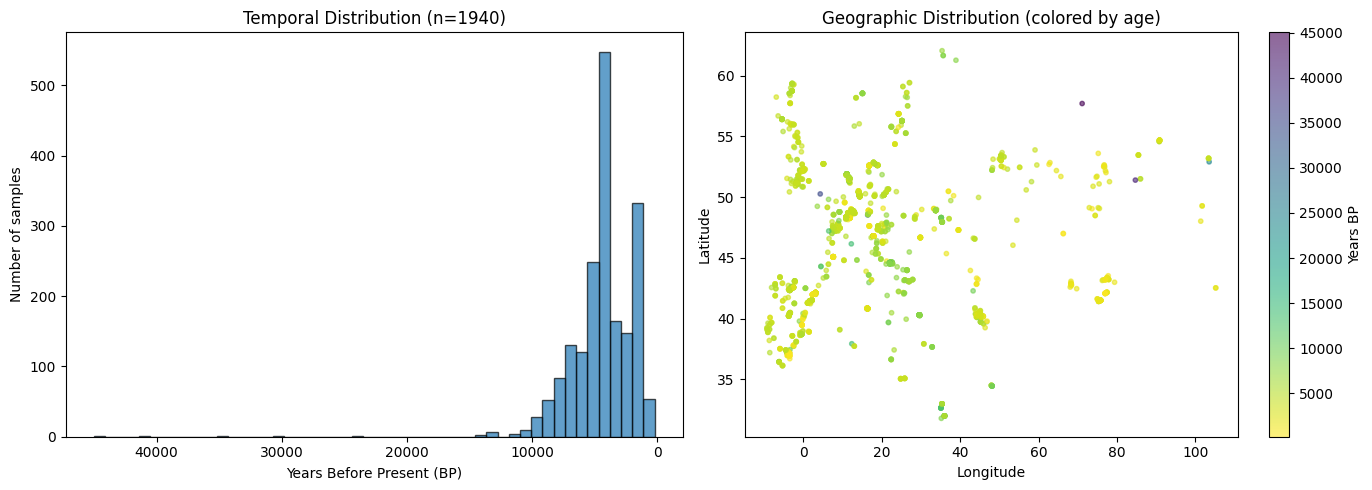

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Temporal distribution
ax = axes[0]
ax.hist(df_meta["date_bp"].dropna(), bins=50, edgecolor="black", alpha=0.7)
ax.set_xlabel("Years Before Present (BP)")
ax.set_ylabel("Number of samples")
ax.set_title(f"Temporal Distribution (n={len(df_meta)})")
ax.invert_xaxis()  # Older dates on left

# Geographic distribution
ax = axes[1]
scatter = ax.scatter(
    df_meta["lon"], df_meta["lat"],
    c=df_meta["date_bp"], cmap="viridis_r",
    alpha=0.6, s=10
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Geographic Distribution (colored by age)")
plt.colorbar(scatter, ax=ax, label="Years BP")

plt.tight_layout()
plt.show()

In [8]:
# Save linked metadata aligned with amtdb_nd_seqs samples
OUTPUT_CSV = DATA_DIR / "amtdb_metadata_linked.csv"

# Select columns for output
cols_out = [
    "sample_id", "group", "epoch", "country", "sex",
    "year_from", "year_to", "date_mid", "date_bp", "date_uncertainty",
    "lat", "lon", "haplogroup"
]
cols_out = [c for c in cols_out if c in df_meta.columns]
df_out = df_meta[cols_out].copy()

# Reindex to match exactly the samples in amtdb_nd_seqs (sorted alphabetically)
df_out = df_out.set_index("sample_id")
df_out = df_out.reindex(sorted(our_sample_ids))
df_out = df_out.reset_index().rename(columns={"index": "sample_id"})

# Report coverage
has_dates = df_out["date_bp"].notna()
has_metadata = df_out["group"].notna()  # proxy for having any metadata
print(f"Metadata output:")
print(f"  Total samples: {len(df_out)} (matches amtdb_nd_seqs)")
print(f"  With metadata: {has_metadata.sum()}")
print(f"  With valid dates: {has_dates.sum()}")
print(f"  Missing dates only: {(has_metadata & ~has_dates).sum()}")
print(f"  Missing all metadata: {(~has_metadata).sum()}")

df_out.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved to {OUTPUT_CSV}")
df_out.head()

Metadata output:
  Total samples: 1940 (matches amtdb_nd_seqs)
  With metadata: 1940
  With valid dates: 1937
  Missing dates only: 3
  Missing all metadata: 0

Saved to amtdb_metadata_linked.csv


,sample_id,group,epoch,country,sex,year_from,year_to,date_mid,date_bp,date_uncertainty,lat,lon,haplogroup
0,19727,NENE,Neolithic,Turkey,M,-6450.0,-6380.0,-6415.0,8365.0,35.0,37.666668,32.828056,K
1,20036,NENE,Neolithic,Turkey,U,-6450.0,-6380.0,-6415.0,8365.0,35.0,37.666668,32.828056,U3b
2,20351,NENE,Neolithic,Turkey,U,-6450.0,-6380.0,-6415.0,8365.0,35.0,37.666668,32.828056,U5b2
3,20374,NENE,Neolithic,Turkey,U,-6450.0,-6380.0,-6415.0,8365.0,35.0,37.666668,32.828056,X2b4
4,30900,NENE,Neolithic,Turkey,U,-6450.0,-6380.0,-6415.0,8365.0,35.0,37.666668,32.828056,U


In [9]:
# Final summary
print("=" * 60)
print("AMTDB METADATA LINKAGE SUMMARY")
print("=" * 60)
print(f"Samples in amtdb_nd_seqs: {len(our_sample_ids)}")
print(f"Samples in output: {len(df_out)}")
print(f"Samples with valid dates: {has_dates.sum()}")
print(f"\nTemporal range (valid samples):")
print(f"  Oldest: {df_out['date_bp'].max():.0f} BP")
print(f"  Youngest: {df_out['date_bp'].min():.0f} BP")
print(f"\nGeographic coverage:")
print(f"  Countries: {df_out['country'].nunique()}")
print(f"  Epochs: {df_out['epoch'].nunique()}")
print(f"\nGenetic diversity:")
print(f"  mtDNA haplogroups: {df_out['haplogroup'].nunique()}")
print(f"\nOutput: {OUTPUT_CSV}")

AMTDB METADATA LINKAGE SUMMARY
Samples in amtdb_nd_seqs: 1940
Samples in output: 1940
Samples with valid dates: 1937

Temporal range (valid samples):
  Oldest: 45020 BP
  Youngest: 200 BP

Geographic coverage:
  Countries: 38
  Epochs: 13

Genetic diversity:
  mtDNA haplogroups: 689

Output: amtdb_metadata_linked.csv
